In [8]:
import pickle as pkl
from matplotlib import pyplot as plt
import pandas as pd
from scipy import stats
import numpy as np
from glob import glob
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

In [2]:
from communication_subspace.ibl_communication.collate_cross_epoch_stats import extract_records

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
df_all = pd.read_parquet("../data/crossprediction_results.pqt")

In [6]:
def filter_df_all(df_all, prior_frame=0, stim_frame=1, choice_frame=2):

    df_single_epoch = df_all[
        (
            (df_all["source_frame"] == prior_frame)
            & (df_all["source_type"] == "Prior")
            & (df_all["choice_frame"] == choice_frame)
        )
        | (
            (df_all["source_frame"] == stim_frame)
            & (df_all["source_type"] == "Stimulus")
            & (df_all["choice_frame"] == choice_frame)
        )
    ]
    return df_single_epoch

In [83]:
def singleregion_summary(df_single_epoch, target_region, plot=True):
    target_data = df_single_epoch[df_single_epoch["region_2"] == target_region]
    # target_data = target_data[target_data["region_1"] != target_region]
    aligned_df = target_data.pivot_table(
        index=["animal_idx", "region_1"], columns="source_type", values="r2_mean"
    ).reset_index()

    epoch_comparisons = []
    source_regions = aligned_df["region_1"].unique()

    for reg_1 in source_regions:

        reg_data = aligned_df[aligned_df["region_1"] == reg_1]
        reg_data = reg_data.dropna(subset=["Stimulus", "Prior"])

        n_animals = len(reg_data)

        if n_animals > 2:
            stat, p_val = stats.ttest_rel(reg_data["Stimulus"], reg_data["Prior"])
            mean_diff = reg_data["Stimulus"].mean() - reg_data["Prior"].mean()

            epoch_comparisons.append(
                {
                    "source_region_1": reg_1,
                    "n_animals_tested": n_animals,
                    "mean_stimulus_r2": reg_data["Stimulus"].mean(),
                    "mean_prior_r2": reg_data["Prior"].mean(),
                    "delta_r2 (stim-prior)": mean_diff,
                    "p_value": p_val,
                    "sem_stimulus_r2": reg_data["Stimulus"].sem(),
                    "sem_prior_r2": reg_data["Prior"].sem(),
                }
            )
    results_df = pd.DataFrame(epoch_comparisons)
    results_df = results_df.dropna(subset=["p_value"])
    results_df["fdr_p_value"] = multipletests(results_df["p_value"], method="fdr_bh")[1]
    results_df["is_significant"] = results_df["fdr_p_value"] < 0.05

    if plot:
        plot_df = results_df.copy().reset_index(drop=True)
        fig, ax = plt.subplots(figsize=(14, 6))

        x = np.arange(len(plot_df))
        width = 0.35

        bars_stim = ax.bar(
            x - width / 2,
            plot_df["mean_stimulus_r2"],
            width,
            yerr=plot_df["sem_stimulus_r2"],
            capsize=2,
            edgecolor="black",
            label="Stimulus Epoch",
            color="#FFB07F",
        )

        bars_prior = ax.bar(
            x + width / 2,
            plot_df["mean_prior_r2"],
            width,
            yerr=plot_df["sem_prior_r2"],
            capsize=2,
            edgecolor="black",
            label="Prior Epoch",
            color="#7FB3D5",
        )

        ax.set_xticks(x)
        ax.set_xticklabels(plot_df["source_region_1"], rotation=90, ha="right")

        max_stim_val = plot_df["mean_stimulus_r2"].max()
        max_prior_val = plot_df["mean_prior_r2"].max()

        if max_stim_val > max_prior_val:
            best_idx = plot_df["mean_stimulus_r2"].idxmax()
        else:
            best_idx = plot_df["mean_prior_r2"].idxmax()

        best_row = plot_df.loc[best_idx]
        max_y_overall = max(
            (plot_df["mean_stimulus_r2"] + plot_df["sem_stimulus_r2"]).max(),
            (plot_df["mean_prior_r2"] + plot_df["sem_prior_r2"]).max(),
        )
        star_offset = max_y_overall * 0.03

        if best_row["is_significant"]:
            if best_row["mean_stimulus_r2"] > best_row["mean_prior_r2"]:
                bar_x = x[best_idx] - width / 2
                bar_y = best_row["mean_stimulus_r2"] + best_row["sem_stimulus_r2"]
            else:
                bar_x = x[best_idx] + width / 2
                bar_y = best_row["mean_prior_r2"] + best_row["sem_prior_r2"]

            ax.text(
                bar_x,
                bar_y + star_offset,
                "*",
                ha="center",
                va="center",
                fontsize=20,
                fontweight="bold",
                color="black",
            )

        for i, tick_label in enumerate(ax.get_xticklabels()):
            if plot_df.iloc[i]["is_significant"]:
                tick_label.set_color("red")

        ax.set_ylabel("Mean R²")
        ax.set_xlabel("Source Region")
        ax.set_title(f"Target: {target_region}")

        ax.legend(loc="upper right")
        # ax.grid(axis='y', linestyle='--', alpha=0.6)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()
    return results_df

In [123]:
results_per_region = []
df_single_epoch = filter_df_all(df_all, prior_frame=0, stim_frame=1, choice_frame=2)
for region in df_single_epoch.region_2.unique():
    results_df = singleregion_summary(
        df_single_epoch=df_single_epoch, target_region=region, plot=False
    )
    results_df["target_region"] = region
    results_per_region.append(results_df)

In [124]:
results_df_global = pd.concat(results_per_region)

In [125]:
results_df_global.columns

Index(['source_region_1', 'n_animals_tested', 'mean_stimulus_r2',
       'mean_prior_r2', 'delta_r2 (stim-prior)', 'p_value', 'sem_stimulus_r2',
       'sem_prior_r2', 'fdr_p_value', 'is_significant', 'target_region'],
      dtype='object')

In [130]:
def plot_animal(df_anima, stim_idx):
    # df_anima = df_anima[
    #     ((df_anima["source_frame"] == 0) & (df_anima["source_type"] == "Prior"))
    #     | ((df_anima["source_frame"] == 1) & (df_anima["source_type"] == "Stimulus"))
    # ]

    best_predictors = (
        df_anima.sort_values("r2_mean", ascending=False)
        .drop_duplicates(subset=["region_2"])
        .sort_values("region_2", ascending=True)
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(16, 7))
    colors = [
        "#FFB07F" if src == "Stimulus" else "#7FB3D5" for src in best_predictors["source_type"]
    ]

    bars = ax.bar(
        best_predictors["region_2"],
        best_predictors["r2_mean"],
        color=colors,
        edgecolor="black",
        linewidth=0.5,
        yerr=best_predictors["r2_std"],
        capsize=3,
        ecolor="black",
    )

    max_y = best_predictors["r2_mean"].max()
    offset = max_y * 0.02

    for i, (bar, source_reg) in enumerate(zip(bars, best_predictors["region_1"])):
        yval = bar.get_height()
        error_val = best_predictors["r2_std"].iloc[i]  # Get the error for this specific bar
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + offset + error_val,
            source_reg,
            ha="center",
            va="bottom",
            rotation=90,  # Rotate 90 degrees so long region names fit
            fontsize=10,
        )

    ax.set_xticks(range(len(best_predictors)))
    ax.set_xticklabels(best_predictors["region_2"], rotation=45, ha="right")

    ax.set_ylabel("R² Score")
    ax.set_xlabel("Target Region")

    ax.set_ylim(0, max_y * 1.4)
    stim_patch = mpatches.Patch(color="#FFB07F", label="Stimulus Epoch")
    prior_patch = mpatches.Patch(color="#7FB3D5", label="Prior Epoch")
    ax.legend(handles=[stim_patch, prior_patch], loc="upper right")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_title(f"Stim frame compared {stim_idx}")
    ax.set_ylim(0, 1.2)
    plt.tight_layout()
    plt.show()

In [131]:
# w1 = pkl.load(
#     open(
#         "../data/crossprediction/2864dca1-38d8-464c-9777-f6fdfd5e63b5_results_prior_choice.pkl",
#         "rb",
#     )
# )
# w2 = pkl.load(
#     open(
#         "../data/crossprediction/2864dca1-38d8-464c-9777-f6fdfd5e63b5_results_stim_choice.pkl",
#         "rb",
#     )
# )
# all_records = []

# records_stim = extract_records(w2, "Stimulus", 1)
# records_prior = extract_records(w1, "Prior", 1)

# all_records.extend(records_stim)
# all_records.extend(records_prior)
# eids = df_all["animal_idx"].unique()

In [132]:
df_anima = df_all[df_all["animal_idx"] == "2864dca1-38d8-464c-9777-f6fdfd5e63b5"]

In [133]:
eids = df_all["animal_idx"].unique()

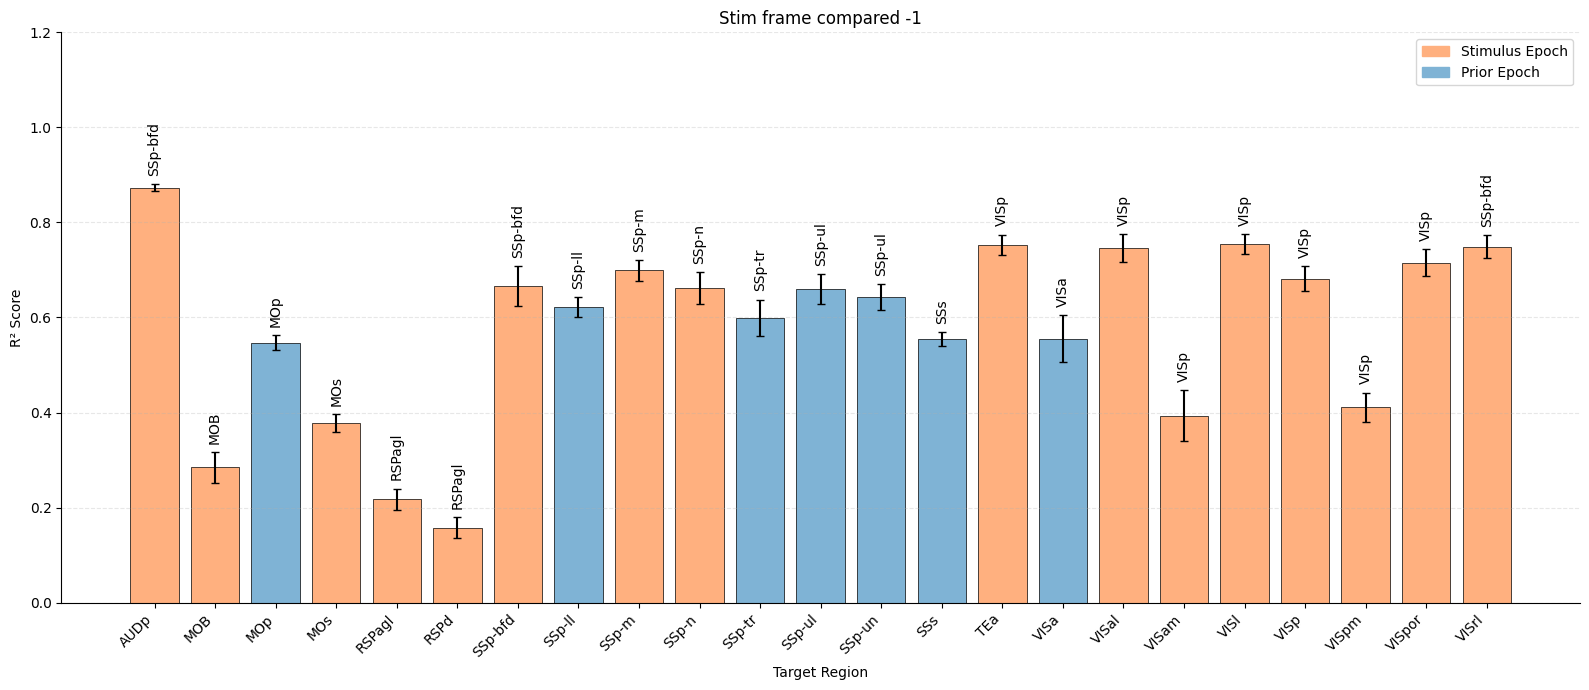

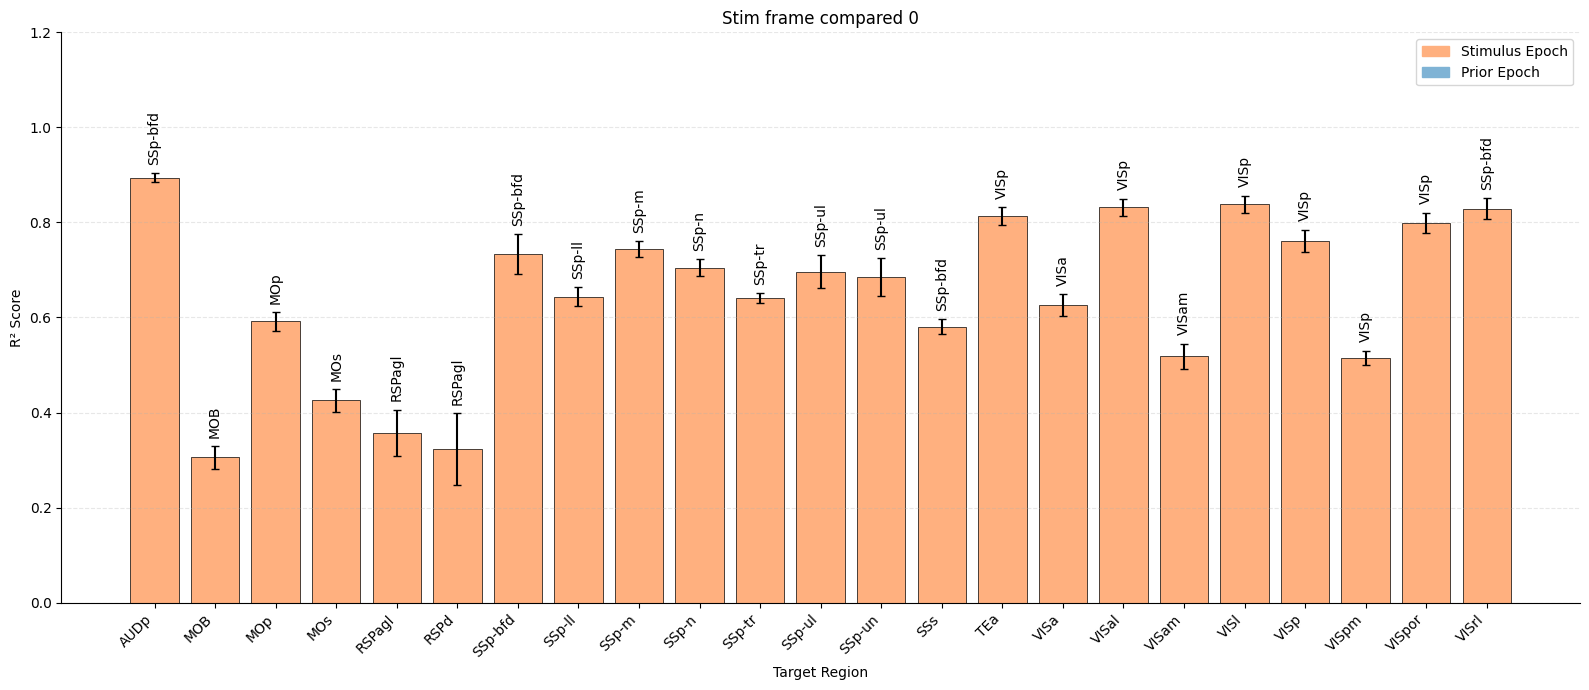

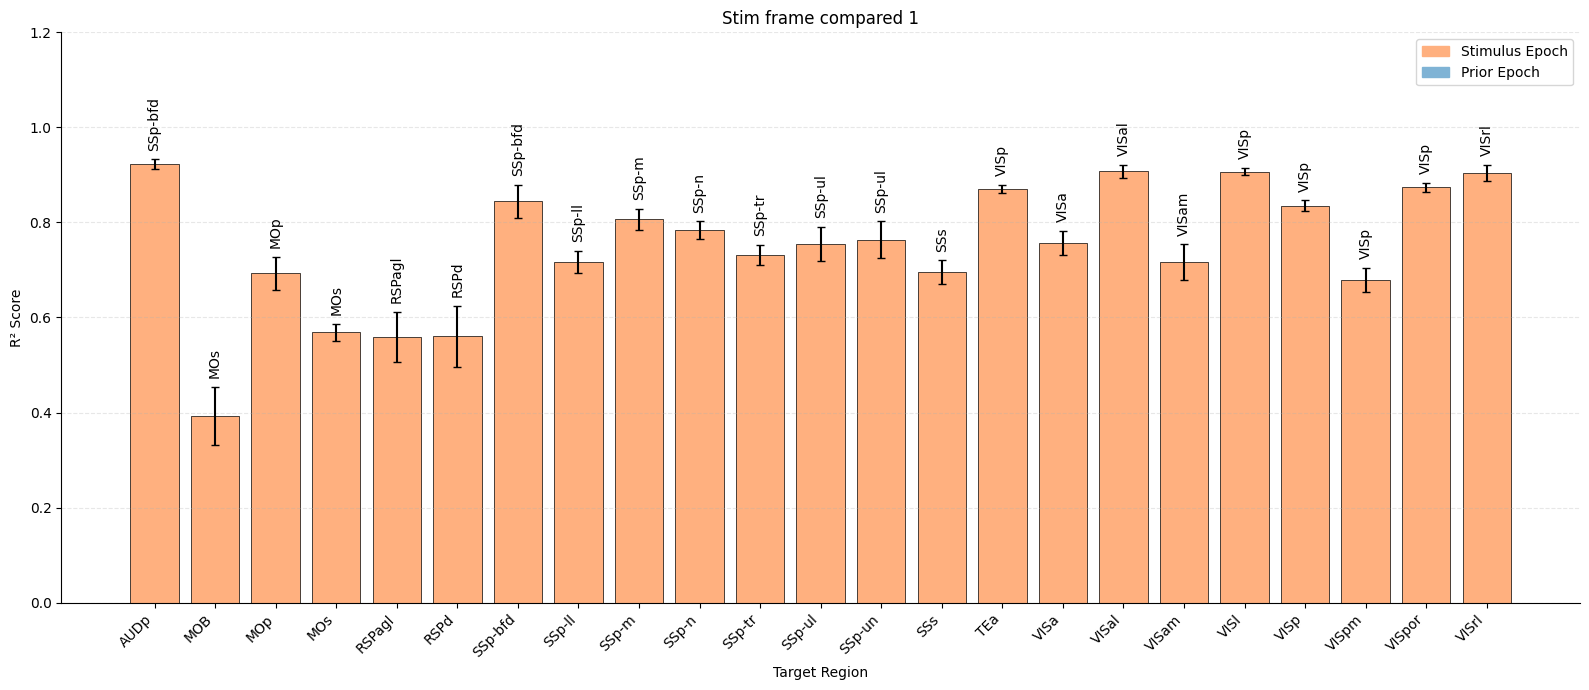

In [134]:
for idx, eid in enumerate(eids):
    df_anima = df_all[df_all["animal_idx"] == eid]
    df_plot = filter_df_all(df_anima, prior_frame=0, stim_frame=0, choice_frame=2)
    plot_animal(df_plot, stim_idx=-1)
    df_plot = filter_df_all(df_anima, prior_frame=0, stim_frame=1, choice_frame=2)
    plot_animal(df_plot, stim_idx=0)
    df_plot = filter_df_all(df_anima, prior_frame=0, stim_frame=2, choice_frame=2)
    plot_animal(df_plot, stim_idx=1)
    break

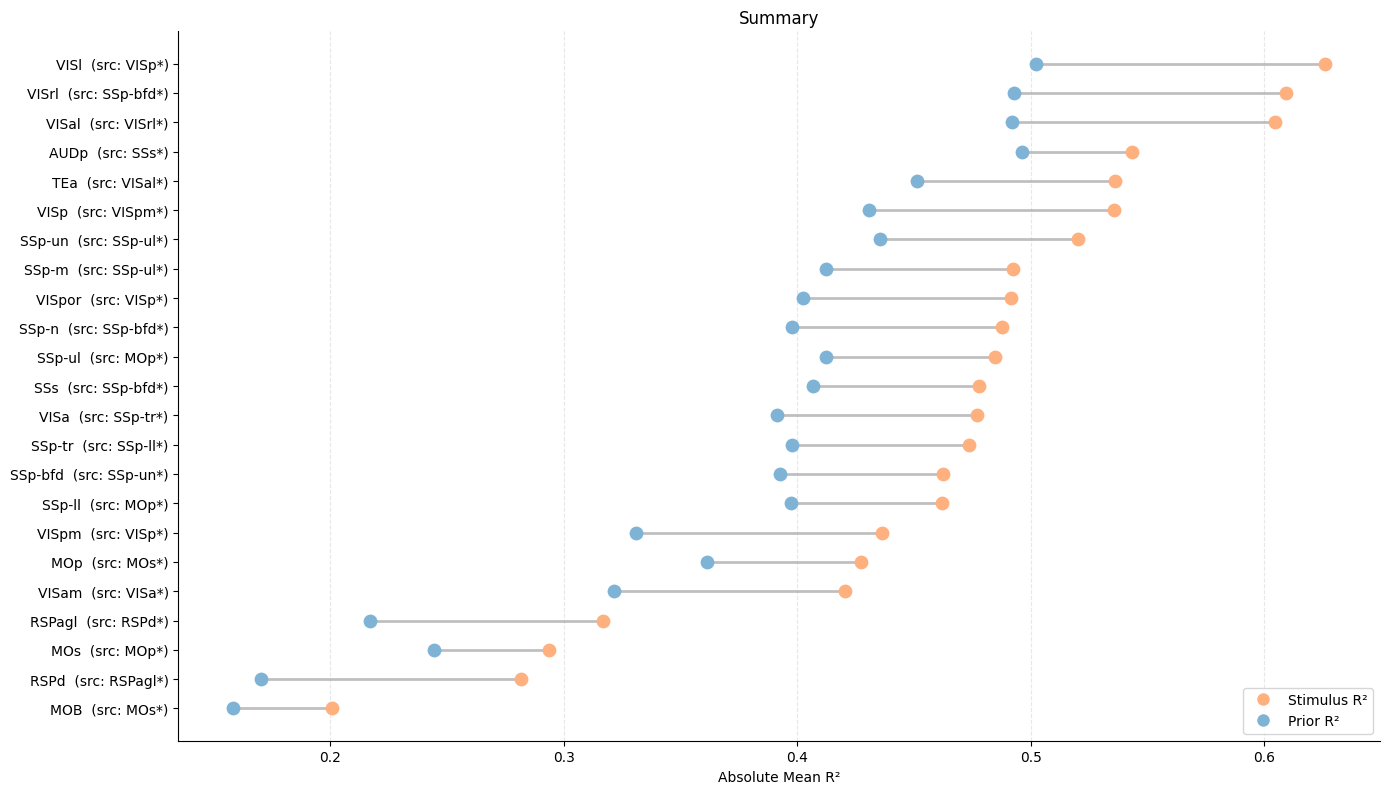

<Figure size 640x480 with 0 Axes>

In [126]:
master_df = results_df_global.copy()
filtered_df = master_df[master_df["source_region_1"] != master_df["target_region"]].copy()

filtered_df["max_overall_r2"] = filtered_df[["mean_stimulus_r2", "mean_prior_r2"]].max(axis=1)
best_overall = filtered_df.sort_values("max_overall_r2", ascending=False).drop_duplicates(
    subset=["target_region"]
)

best_overall = best_overall.sort_values("max_overall_r2", ascending=True).reset_index(drop=True)
# best_overall = best_overall.sort_values("target_region", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, max(8, len(best_overall) * 0.35)))


for i, row in best_overall.iterrows():
    y = i
    x_prior = row["mean_prior_r2"]
    x_stim = row["mean_stimulus_r2"]

    ax.plot([x_prior, x_stim], [y, y], color="gray", alpha=0.5, linewidth=2, zorder=1)
    ax.scatter(x_prior, y, color="#7FB3D5", s=80, zorder=2, label="Prior" if i == 0 else "")
    ax.scatter(x_stim, y, color="#FFB07F", s=80, zorder=2, label="Stimulus" if i == 0 else "")


ylabels = []
for _, row in best_overall.iterrows():
    star = "*" if row["is_significant"] else ""
    label = f"{row['target_region']}  (src: {row['source_region_1']}{star})"
    ylabels.append(label)

ax.set_yticks(range(len(best_overall)))
ax.set_yticklabels(ylabels)

# for i, tick_label in enumerate(ax.get_yticklabels()):
#     if best_overall.iloc[i]["is_significant"]:
#         tick_label.set_color("red")  # Or 'red' if you prefer
#         tick_label.set_fontweight("bold")

# 7. CLEAN UP
ax.set_xlabel("Absolute Mean R²")
ax.set_title("Summary")

# Custom Legend
stim_patch = plt.Line2D(
    [0],
    [0],
    marker="o",
    color="w",
    markerfacecolor="#FFB07F",
    markersize=10,
    label="Stimulus R²",
)
prior_patch = plt.Line2D(
    [0],
    [0],
    marker="o",
    color="w",
    markerfacecolor="#7FB3D5",
    markersize=10,
    label="Prior R²",
)
ax.legend(handles=[stim_patch, prior_patch], loc="lower right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

In [135]:
df_all

,animal_idx,region_1,region_2,source_type,source_frame,choice_frame,r2_mean,r2_std
0,12046ccd-b737-4c01-bc70-400f3b69291b,AUDp,AUDp,Stimulus,0,0,0.925575,0.007682
1,12046ccd-b737-4c01-bc70-400f3b69291b,AUDp,AUDp,Stimulus,0,1,0.878107,0.008371
2,12046ccd-b737-4c01-bc70-400f3b69291b,AUDp,AUDp,Stimulus,0,2,0.859618,0.006601
3,12046ccd-b737-4c01-bc70-400f3b69291b,AUDp,AUDp,Stimulus,1,0,0.948375,0.005382
4,12046ccd-b737-4c01-bc70-400f3b69291b,AUDp,AUDp,Stimulus,1,1,0.920380,0.009698
...,...,...,...,...,...,...,...,...
308371,ff7a70f5-a2b6-4e7e-938e-e7208e0678c2,VISrl,VISpor,Prior,0,1,0.288470,0.126346
308372,ff7a70f5-a2b6-4e7e-938e-e7208e0678c2,VISrl,VISpor,Prior,0,2,0.219621,0.096827
308373,ff7a70f5-a2b6-4e7e-938e-e7208e0678c2,VISrl,VISrl,Prior,0,0,0.525127,0.117539
308374,ff7a70f5-a2b6-4e7e-938e-e7208e0678c2,VISrl,VISrl,Prior,0,1,0.441234,0.152904


In [145]:
def plot_frame_dynamics(df, target_reg, source_reg):
    plot_df = df[
        (df["region_2"] == target_reg)
        & (df["region_1"] == source_reg)
        & (df["source_type"] == "Stimulus")
    ].copy()

    if plot_df.empty:
        print(f"No data found for Target: {target_reg} and Source: {source_reg}")
        return

    frame_mapping = {2: "Movement Onset", 1: "-1 Frame", 0: "-2 Frames"}
    plot_df["choice_frame"] = plot_df["choice_frame"].map(frame_mapping)
    plot_df["source_frame"] = plot_df["source_frame"].astype(int)

    fig, ax = plt.subplots(figsize=(10, 6))
    logical_order = ["-2 Frames", "-1 Frame", "Movement Onset"]

    # 4. Plot using Seaborn
    sns.lineplot(
        data=plot_df,
        x="source_frame",
        y="r2_mean",
        hue="choice_frame",
        hue_order=logical_order,  # Forces the legend into chronological order
        style="choice_frame",
        style_order=logical_order,  # Ensures line dash styles match the order
        markers=True,
        dashes=False,
        markersize=8,
        linewidth=2,
        palette="Set2",
        errorbar="se",
        err_style="bars",
        err_kws={"capsize": 4},
        ax=ax,
    )

    # 5. Clean up aesthetics
    ax.set_title(
        f"{source_reg} -> {target_reg}",
        fontsize=14,
    )
    ax.set_xlabel("Source Frame", fontsize=12)
    ax.set_ylabel("Mean R²", fontsize=12)

    source_mapping = {0: "-1 Frame", 1: "Stim Onset", 2: "+1 Frame"}

    frames = sorted(plot_df["source_frame"].unique())
    ax.set_xticks(frames)
    tick_labels = [source_mapping.get(f, f"Frame {f}") for f in frames]
    ax.set_xticklabels(tick_labels)

    # Clean up the legend
    ax.legend(loc="best", frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

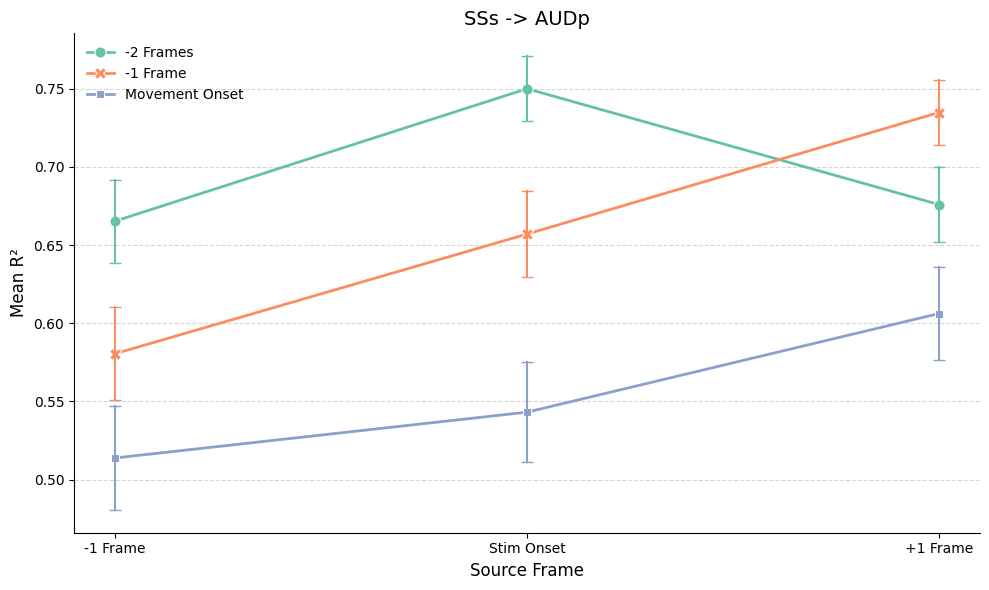

In [151]:
plot_frame_dynamics(df_all, target_reg="AUDp", source_reg="SSs")